# Notebook 1: Natural Resource Prices - Data Cleaning

**Source:** Kaggle - Historical Prices of Major Natural Resources  
**Granularity:** Daily --> Monthly (resampled)  
**Scope:** 2020–2025 (COVID era through 2nd Trump administration)  
**Focus columns for this project:** `Date`, `WTI_Crude`, `Brent_Crude`, `Natural_Gas`  

**Pipeline steps covered:** Data Ingestion --> Data Cleaning --> Data Wrangling

**Contributors**: Joan Ojukwu

## 1. Imports & Configuration

In [1]:
import pandas as pd # for loading + manipulating data
import numpy as np # for math
import matplotlib.pyplot as plt # for drawing charts
import matplotlib.dates as mdates # formats date labels on chart axes
import warnings

# Date range of interest
START_DATE = '2020-01-01' # earliest date we want to keep
END_DATE   = '2025-12-31' # latest date we want to keep

# Columns we keep for this project
COMMODITY_COLS = ['CL=F_Close', 'BZ=F_Close', 'NG=F_Close']
#                  WTI Crude     Brent Crude   Natural Gas

print('Libraries loaded.')

Libraries loaded.


## 2. Data Ingestion

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the raw CSV
RAW_PATH = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/InputCSVfiles/Resources_Dataset.csv'

df_raw = pd.read_csv(RAW_PATH)

print(f'Raw shape: {df_raw.shape}')
print(f'Columns  : {list(df_raw.columns)}')
df_raw.head() # shows the first 5 row

Raw shape: (7000, 23)
Columns  : ['Date', 'CL=F_Close', 'CL=F_Volume', 'BZ=F_Close', 'BZ=F_Volume', 'GC=F_Close', 'GC=F_Volume', 'SI=F_Close', 'SI=F_Volume', 'NG=F_Close', 'NG=F_Volume', 'ZC=F_Close', 'ZC=F_Volume', 'ZW=F_Close', 'ZW=F_Volume', 'ZS=F_Close', 'ZS=F_Volume', 'HG=F_Close', 'HG=F_Volume', 'PL=F_Close', 'PL=F_Volume', 'PA=F_Close', 'PA=F_Volume']


,Date,CL=F_Close,CL=F_Volume,BZ=F_Close,BZ=F_Volume,GC=F_Close,GC=F_Volume,SI=F_Close,SI=F_Volume,NG=F_Close,...,ZW=F_Close,ZW=F_Volume,ZS=F_Close,ZS=F_Volume,HG=F_Close,HG=F_Volume,PL=F_Close,PL=F_Volume,PA=F_Close,PA=F_Volume
0,29/10/1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,402.700012,1708.0,NaN,NaN
1,30/10/1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,405.299988,1305.0,NaN,NaN
2,31/10/1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,404.200012,862.0,NaN,NaN
3,3/11/1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,406.500000,898.0,NaN,NaN
4,4/11/1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,405.700012,809.0,NaN,NaN


## 3. Initial Inspection

In [ ]:
# Data types & nulls
print('dtypes')
print(df_raw.dtypes) # counts null values per column
print()
print('Missing values (count & %)')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2) # converts counts to percentages
print(pd.concat([missing, missing_pct], axis=1, keys=['count', '%']))

dtypes
Date            object
CL=F_Close     float64
CL=F_Volume    float64
BZ=F_Close     float64
BZ=F_Volume    float64
GC=F_Close     float64
GC=F_Volume    float64
SI=F_Close     float64
SI=F_Volume    float64
NG=F_Close     float64
NG=F_Volume    float64
ZC=F_Close     float64
ZC=F_Volume    float64
ZW=F_Close     float64
ZW=F_Volume    float64
ZS=F_Close     float64
ZS=F_Volume    float64
HG=F_Close     float64
HG=F_Volume    float64
PL=F_Close     float64
PL=F_Volume    float64
PA=F_Close     float64
PA=F_Volume    float64
dtype: object

Missing values (count & %)
             count      %
Date             0   0.00
CL=F_Close     728  10.40
CL=F_Volume    728  10.40
BZ=F_Close    2510  35.86
BZ=F_Volume   2510  35.86
GC=F_Close     737  10.53
GC=F_Volume    737  10.53
SI=F_Close     735  10.50
SI=F_Volume    735  10.50
NG=F_Close     731  10.44
NG=F_Volume    731  10.44
ZC=F_Close     725  10.36
ZC=F_Volume    725  10.36
ZW=F_Close     713  10.19
ZW=F_Volume    713  10.19
ZS=F_C

In [ ]:
# Descriptive statistics
df_raw.describe()

,CL=F_Close,CL=F_Volume,BZ=F_Close,BZ=F_Volume,GC=F_Close,GC=F_Volume,SI=F_Close,SI=F_Volume,NG=F_Close,NG=F_Volume,...,ZW=F_Close,ZW=F_Volume,ZS=F_Close,ZS=F_Volume,HG=F_Close,HG=F_Volume,PL=F_Close,PL=F_Volume,PA=F_Close,PA=F_Volume
count,6272.000000,6.272000e+03,4490.000000,4490.000000,6263.000000,6263.000000,6265.000000,6265.000000,6269.000000,6269.000000,...,6287.000000,6287.000000,6267.000000,6267.000000,6268.000000,6268.000000,6291.000000,6291.000000,6302.000000,6302.000000
mean,64.725607,3.035280e+05,78.333984,19462.463920,1210.522114,4309.121507,17.471016,1455.549721,4.406801,105653.055830,...,537.952442,33518.614761,1006.557085,52138.108186,2.811601,1282.172782,997.571244,426.208711,843.618716,177.405427
std,24.764567,2.085609e+05,23.968607,17602.591524,652.149206,24223.475449,8.809352,8464.265554,2.217520,64282.065305,...,180.375899,32572.684528,327.911934,56811.096342,1.150969,5132.330332,388.389627,1280.773590,621.903493,628.506907
min,-37.630001,0.000000e+00,19.330000,0.000000,255.100006,0.000000,4.026000,0.000000,1.482000,0.000000,...,233.500000,0.000000,418.500000,0.000000,0.604000,0.000000,336.399994,0.000000,148.500000,0.000000
25%,46.057501,1.214415e+05,60.779999,1410.250000,644.350006,22.000000,11.932000,5.000000,2.791000,47436.000000,...,407.250000,326.000000,805.875000,778.000000,2.116500,266.000000,802.300018,0.000000,353.887505,0.000000
50%,64.030003,2.761055e+05,76.079998,19715.500000,1244.000000,112.000000,16.906000,36.000000,3.761000,101683.000000,...,520.000000,31577.000000,984.250000,26725.000000,3.029250,416.000000,948.200012,8.000000,708.100006,3.000000
75%,82.309998,3.935375e+05,98.412498,31922.250000,1659.649964,426.000000,23.149000,138.000000,5.548000,148765.000000,...,647.250000,57118.500000,1286.875000,98779.500000,3.647500,680.000000,1237.299988,238.500000,998.275024,60.000000
max,145.289993,2.288230e+06,146.080002,175031.000000,3439.199951,386334.000000,48.584000,170297.000000,15.378000,459196.000000,...,1425.250000,166632.000000,1771.000000,352462.000000,5.795000,79408.000000,2251.100098,17489.000000,2985.399902,11174.000000


## 4. Date Parsing & Column Selection

In [ ]:
# Identify the date column
DATE_COL = 'Date'

df = df_raw.copy() # work on a copy so the original stays untouched
# converts text dates to real datetime objects
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
# makes the date the row & label sorts oldest to newest
df = df.set_index(DATE_COL).sort_index()


print(f'Date range in raw data: {df.index.min().date()} to {df.index.max().date()}')

# Keep only the columns that're relevant
keep_cols = [c for c in COMMODITY_COLS if c in df.columns]
# only keeps columns that actually exist
# guards against typos or missing fields
missing_cols = set(COMMODITY_COLS) - set(keep_cols)
if missing_cols:
    print(f'WARNING: Columns not found and will be skipped: {missing_cols}')

df = df[keep_cols] # drops all columns except WTI, Brent, Natural Gas
df = df.rename(columns={  # renames ticker codes to readable names
    'CL=F_Close': 'WTI_Crude',
    'BZ=F_Close': 'Brent_Crude',
    'NG=F_Close': 'Natural_Gas',
})
keep_cols = df.columns.tolist()  # update keep_cols to the new names
print(f'Columns kept: {keep_cols}')
df.head()

Date range in raw data: 1997-10-29 → 2025-08-15
Columns kept: ['WTI_Crude', 'Brent_Crude', 'Natural_Gas']


,WTI_Crude,Brent_Crude,Natural_Gas
Date,,,
1997-10-29,NaN,NaN,NaN
1997-10-30,NaN,NaN,NaN
1997-10-31,NaN,NaN,NaN
1997-11-03,NaN,NaN,NaN
1997-11-04,NaN,NaN,NaN


## 5. Filter to Date Range of Interest

In [ ]:
df = df.loc[START_DATE:END_DATE] # keeps only rows between 2020-01-01 and 2025-12-31
print(f'After date filter — shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')

After date filter — shape: (1416, 3)
Date range: 2020-01-02 → 2025-08-15


## 6. Handle Missing Values


- **Weekends / market holidays** are expected gaps --> fill forward first, then backward.
- Interpolate linearly between the last known and next known value.
- Flag any remaining nulls after imputation.

In [ ]:
full_daily_index = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
# creates a complete list of every calendar day in the range
df = df.reindex(full_daily_index)

print(f'Nulls BEFORE imputation:')
print(df.isnull().sum()) # shows how many nulls exist before we fix them

df_filled = df.ffill(limit=3)   # cap at 3 consecutive days (covers weekends)

# fills longer gaps by drawing a straight line between known values
df_filled = df_filled.interpolate(method='linear', limit_direction='both')

# catches any nulls at start of the dataset where ffill can't reach
df_filled = df_filled.bfill()

print(f'\nNulls AFTER imputation:')
print(df_filled.isnull().sum()) #should be 0

Nulls BEFORE imputation:
WTI_Crude      777
Brent_Crude    776
Natural_Gas    776
dtype: int64

Nulls AFTER imputation:
WTI_Crude      0
Brent_Crude    0
Natural_Gas    0
dtype: int64


In [ ]:
print(f"keep_cols: {keep_cols}")
print(f"df columns: {df.columns.tolist()}")

# Use all numeric columns if keep_cols is empty
if not keep_cols:
    keep_cols = df.select_dtypes(include='number').columns.tolist()
print(keep_cols)

keep_cols: ['WTI_Crude', 'Brent_Crude', 'Natural_Gas']
df columns: ['WTI_Crude', 'Brent_Crude', 'Natural_Gas']
['WTI_Crude', 'Brent_Crude', 'Natural_Gas']


In [ ]:
import os
print(os.getcwd())                          # where Python thinks you are
print(os.path.exists(RAW_PATH))             # is the file actually there
print(df_raw.shape)                         # did it load anything
print(df_raw.columns.tolist())              # what columns came in?

/content
False
(7000, 23)
['Date', 'CL=F_Close', 'CL=F_Volume', 'BZ=F_Close', 'BZ=F_Volume', 'GC=F_Close', 'GC=F_Volume', 'SI=F_Close', 'SI=F_Volume', 'NG=F_Close', 'NG=F_Volume', 'ZC=F_Close', 'ZC=F_Volume', 'ZW=F_Close', 'ZW=F_Volume', 'ZS=F_Close', 'ZS=F_Volume', 'HG=F_Close', 'HG=F_Volume', 'PL=F_Close', 'PL=F_Volume', 'PA=F_Close', 'PA=F_Volume']


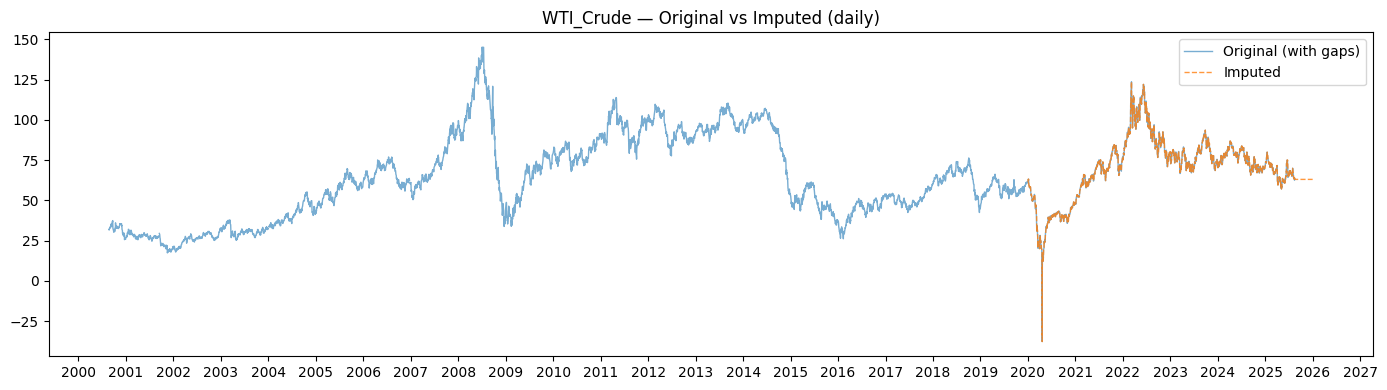

['WTI_Crude', 'Brent_Crude', 'Natural_Gas']

In [ ]:
# Visualise imputation quality for WTI Crude
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df[keep_cols[0]], label='Original (with gaps)', alpha=0.6, lw=1)
ax.plot(df_filled.index, df_filled[keep_cols[0]], label='Imputed', alpha=0.8, lw=1, ls='--')
ax.set_title(f'{keep_cols[0]} — Original vs Imputed (daily)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/commodity_imputation_check.png', dpi=150)
plt.show()
df.columns.tolist()


## 7. Resample: Daily → Monthly

Using **month-end mean** so every row represents one calendar month.  
The output date will be the last day of each month (`'ME'` frequency).

In [ ]:
df_monthly = df_filled.resample('ME').mean().round(4)
# groups all daily rows by month-end
# takes the average price for each month
# 'ME' = month-end frequency (Ex: 2020-01-31, 2020-02-29)
# .round(4) keeps 4 decimal places

# Rename index to 'YearMonth' for clarity in joins
df_monthly.index.name = 'YearMonth'

print(f'Monthly shape: {df_monthly.shape}')
df_monthly.head(12) # shows the first year of monthly data to verify

Monthly shape: (72, 3)


,WTI_Crude,Brent_Crude,Natural_Gas
YearMonth,,,
2020-01-31,57.9826,64.0303,2.0390
2020-02-29,50.7493,55.7455,1.8423
2020-03-31,30.5955,34.0200,1.7226
2020-04-30,18.2020,27.3653,1.7462
2020-05-31,28.6832,32.2900,1.7997
2020-06-30,38.3667,40.8493,1.6924
2020-07-31,40.7632,43.2313,1.7643
2020-08-31,42.1861,44.8135,2.3293
2020-09-30,39.6277,41.8997,2.2854


## 8. Outlier Check

In [ ]:
for col in keep_cols:
    Q1, Q3 = df_monthly[col].quantile([0.25, 0.75]) # finds the 25th and 75th percentile
    IQR = Q3 - Q1 # interquartile range = spread of the middle 50%
    outliers = df_monthly[(df_monthly[col] < Q1 - 1.5*IQR) | (df_monthly[col] > Q3 + 1.5*IQR)]
    # flags any values more than 1.5× the IQR below Q1 or above Q3
    if not outliers.empty:
        print(f'[{col}] Potential outliers ({len(outliers)} months):')
        print(outliers[[col]]) # prints the flagged months and their values
        print()
    else:
        print(f'[{col}] No outliers detected.')

# April 2020 WTI crash (at $18)to negative values is REAL
# and June 2022 at $114
# (COVID crash, Ukraine war spike)

[WTI_Crude] Potential outliers (6 months):
            WTI_Crude
YearMonth            
2020-03-31    30.5955
2020-04-30    18.2020
2020-05-31    28.6832
2022-03-31   108.9435
2022-05-31   110.0429
2022-06-30   114.1373

[Brent_Crude] Potential outliers (6 months):
            Brent_Crude
YearMonth              
2020-03-31      34.0200
2020-04-30      27.3653
2020-05-31      32.2900
2022-03-31     113.0765
2022-05-31     112.3242
2022-06-30     117.3333

[Natural_Gas] Potential outliers (8 months):
            Natural_Gas
YearMonth              
2022-04-30       6.6767
2022-05-31       8.1431
2022-06-30       7.5858
2022-07-31       7.0995
2022-08-31       8.8018
2022-09-30       7.8147
2022-10-31       6.0969
2022-11-30       6.4515



## 9. Final Validation & Save

In [ ]:
print('Final dataset info')
print(f'Shape      : {df_monthly.shape}')
print(f'Date range : {df_monthly.index.min()} → {df_monthly.index.max()}')
print(f'Nulls      : {df_monthly.isnull().sum().sum()}')
print()
print(df_monthly.describe())

Final dataset info
Shape      : (72, 3)
Date range : 2020-01-31 00:00:00 → 2025-12-31 00:00:00
Nulls      : 0

        WTI_Crude  Brent_Crude  Natural_Gas
count   72.000000    72.000000    72.000000
mean    70.176011    73.937074     3.460535
std     18.399740    18.641734     1.673806
min     18.202000    27.365300     1.692400
25%     63.061425    65.000000     2.421575
50%     71.542900    75.043100     2.927000
75%     79.564125    83.664850     3.818775
max    114.137300   117.333300     8.801800


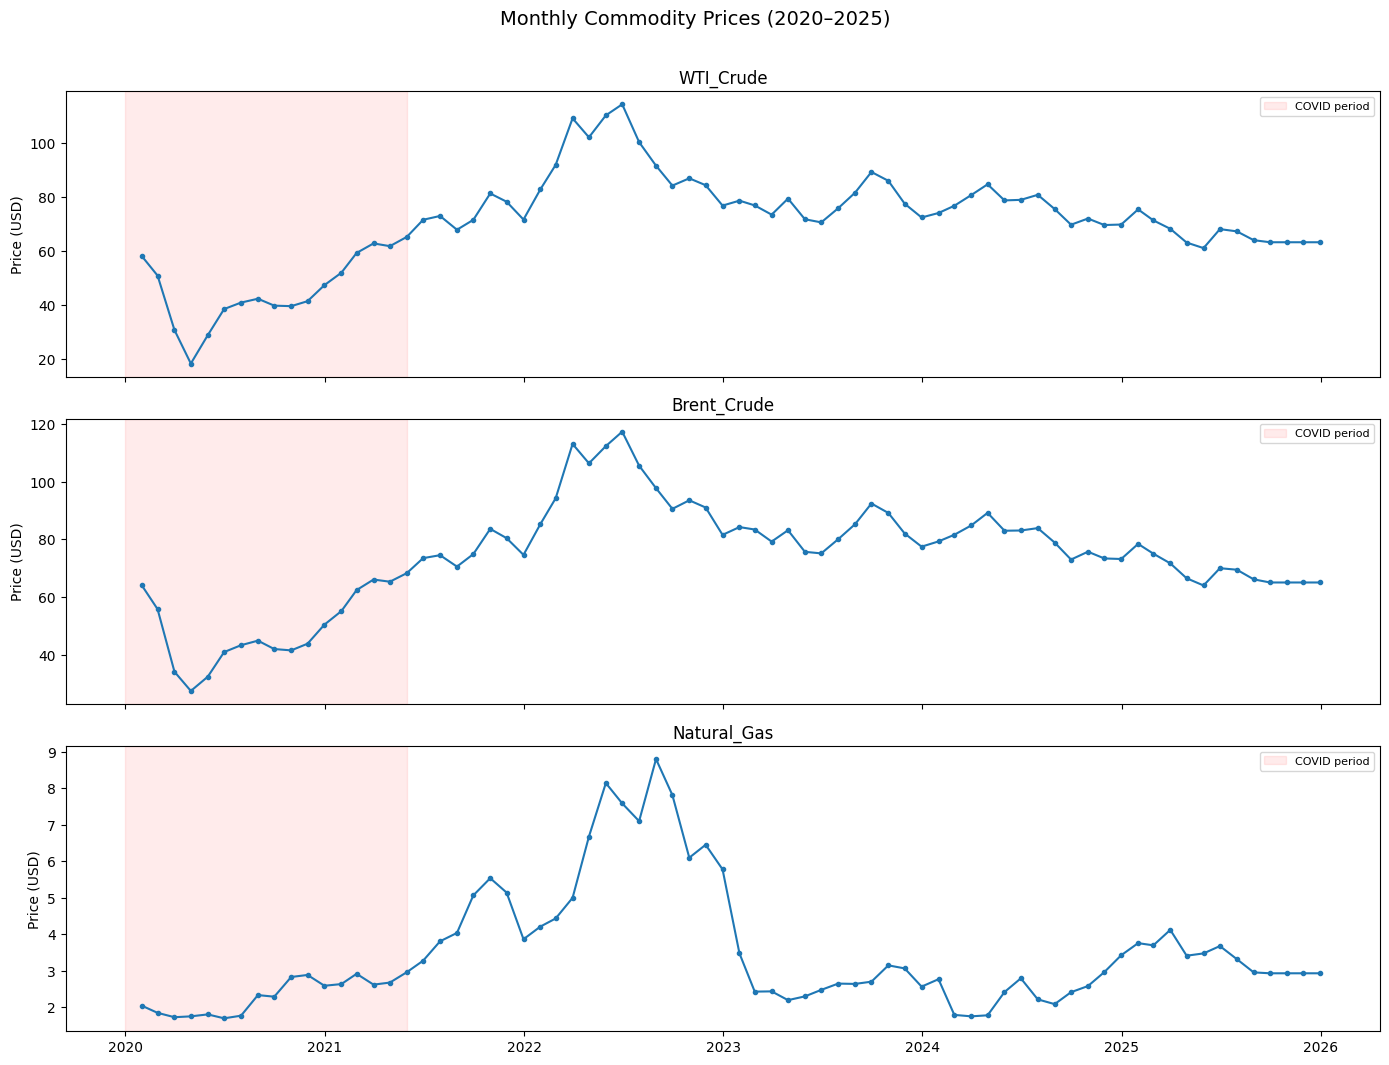

In [ ]:
# Plot all three price series
fig, axes = plt.subplots(len(keep_cols), 1, figsize=(14, 3.5 * len(keep_cols)), sharex=True)
if len(keep_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, keep_cols):
    ax.plot(df_monthly.index, df_monthly[col], lw=1.5, marker='o', markersize=3)
    ax.set_title(col)
    ax.set_ylabel('Price (USD)')
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
               alpha=0.08, color='red', label='COVID period')
    ax.legend(fontsize=8)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Monthly Commodity Prices (2020–2025)', fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs('data/clean', exist_ok=True)
plt.savefig('figures/commodity_prices_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save clean output
OUT_PATH = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/commodity_prices_monthly.csv'
os.makedirs('data/clean', exist_ok=True)
df_monthly.to_csv(OUT_PATH)
print(f'Saved → {OUT_PATH}')

Saved → /content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/commodity_prices_monthly.csv


## 10. Cleaning Summary

| Step | Action | Rationale |
|------|--------|-----------|
| Column selection | Kept WTI, Brent, Natural Gas only | Scope-focused; others not needed for channel analysis |
| Date filter | 2020-01-01 → 2025-12-31 | COVID era through 2nd Trump administration |
| Reindex to calendar | Expanded to full daily index | Makes gaps explicit before imputation |
| Forward-fill (limit=3) | Covers weekends & market holidays | Standard practice for market data |
| Linear interpolation | Fills multi-day gaps | Recommended by dataset documentation |
| Monthly resampling | Mean per calendar month | Aligns with CPI-U and PortWatch monthly data |
| Outlier review | Flagged, NOT removed | Apr 2020 WTI crash is a real economic event |

**Output:** `/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/commodity_prices_monthly.csv`  
**Join key:** `YearMonth` (month-end date, e.g. `2020-01-31`)